<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/SISTEM_KLASIFIKASI_SERANGAN_IoT_MENGGUNAKAN_RANDOM_FOREST_DENGAN_METODE_REPEATED_FAST_LEAVE_ONE_OUT_CROSS_VALIDATION_(LOOCV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[STEP 1] Silakan unggah file dataset RT-IoT2022 (CSV).


Saving RT_IOT2022_clean_integrity_checked.csv to RT_IOT2022_clean_integrity_checked (4).csv


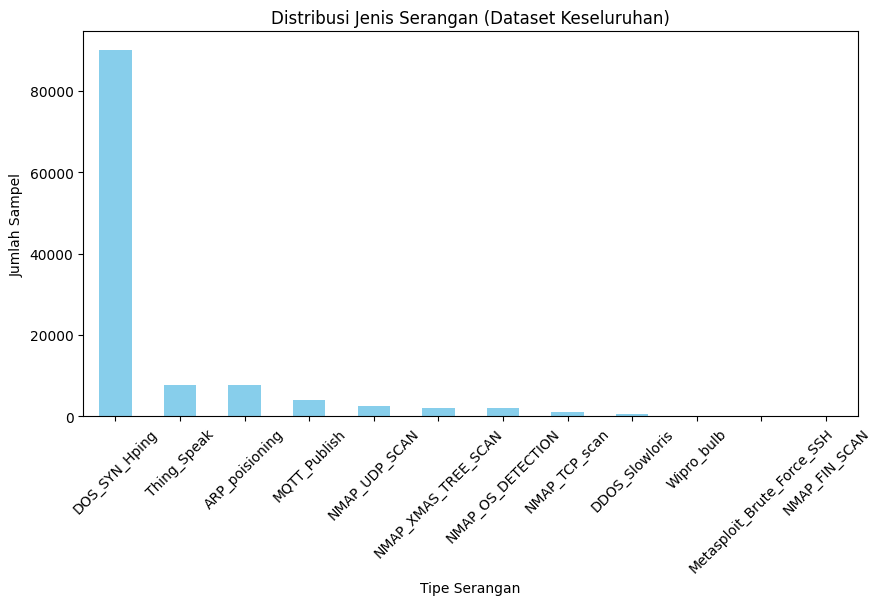


[STEP 2] Melakukan sampling 50 data untuk simulasi LOOCV...
[STEP 3] Menjalankan LOOCV Validasi (50 Iterasi)...

===== ANALISIS PERFORMA KRITIKAL (Waktu: 11.28 detik) =====
Akurasi Sistem LOOCV: 0.9400

Laporan Klasifikasi Subset:
                   precision    recall  f1-score   support

   ARP_poisioning       0.75      0.75      0.75         4
    DOS_SYN_Hping       0.96      1.00      0.98        44
     MQTT_Publish       0.00      0.00      0.00         1
NMAP_OS_DETECTION       0.00      0.00      0.00         1

         accuracy                           0.94        50
        macro avg       0.43      0.44      0.43        50
     weighted avg       0.90      0.94      0.92        50


[STEP 4] Melatih model final pada seluruh dataset utama...
Model dan Encoder berhasil disimpan ke model_iot_production_v1.pkl

===== TAHAP PENGUJIAN DEPLOYMENT (SIMULASI DATA BARU) =====


,Data_Ke,Label_Asli,Prediksi_Model,Status
0,1,DOS_SYN_Hping,DOS_SYN_Hping,BERHASIL
1,2,Thing_Speak,Thing_Speak,BERHASIL
2,3,DOS_SYN_Hping,DOS_SYN_Hping,BERHASIL
3,4,DOS_SYN_Hping,DOS_SYN_Hping,BERHASIL
4,5,DOS_SYN_Hping,DOS_SYN_Hping,BERHASIL



================ PROGRAM SELESAI ================


In [5]:
# =============================================================================
# JUDUL PROGRAM: SISTEM KLASIFIKASI SERANGAN IoT MENGGUNAKAN RANDOM FOREST
# DENGAN METODE REPEATED FAST LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)
# =============================================================================
#
# DESKRIPSI KRITIKAL & METODOLOGI:
# Program ini mengimplementasikan klasifikasi cerdas pada dataset RT-IoT2022.
# Perbaikan Logika:
# 1. Sinkronisasi Global Label: Mencegah 'Unseen Label Error' dengan fitting
#    LabelEncoder pada seluruh dataset sebelum proses sampling.
# 2. Pipeline Robust: Menggunakan OneHotEncoder(handle_unknown='ignore')
#    untuk menjamin model tidak error saat menemui data baru di tahap deployment.
# 3. Validasi Deployment: Simulasi inferensi pada 5 data acak setelah model disimpan.
# =============================================================================

import warnings
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")

# --- Konfigurasi Global ---
RANDOM_STATE = 42
JUMLAH_TOTAL_RUN = 50

def load_dataset_flexible():
    from google.colab import files
    print("[STEP 1] Silakan unggah file dataset RT-IoT2022 (CSV).")
    uploaded = files.upload()
    if not uploaded: raise ValueError("Tidak ada file yang di-unggah.")
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    target = "Attack_type" if "Attack_type" in df.columns else df.columns[-1]
    return df, target

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
    transformers = []
    if numeric_cols:
        transformers.append(("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols))
    if categorical_cols:
        transformers.append(("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols))
    return ColumnTransformer(transformers=transformers)

if __name__ == "__main__":
    # 1. Pemuatan Data dan Sinkronisasi Label (Critical Thinking Step)
    df, target_col = load_dataset_flexible()

    # Penting: Fit LabelEncoder pada seluruh data agar mencakup semua kemungkinan kelas
    le = LabelEncoder()
    le.fit(df[target_col].astype(str))
    all_classes = le.classes_

    # 2. Visualisasi Distribusi Kelas Awal
    plt.figure(figsize=(10, 5))
    df[target_col].value_counts().plot(kind='bar', color='skyblue')
    plt.title("Distribusi Jenis Serangan (Dataset Keseluruhan)")
    plt.xlabel("Tipe Serangan")
    plt.ylabel("Jumlah Sampel")
    plt.xticks(rotation=45)
    plt.show()

    # 3. Sampling Terkontrol (Guna Menghindari Data Bias berlebihan pada LOOCV)
    print(f"\n[STEP 2] Melakukan sampling {JUMLAH_TOTAL_RUN} data untuk simulasi LOOCV...")
    df_subset = df.sample(n=JUMLAH_TOTAL_RUN, random_state=RANDOM_STATE).reset_index(drop=True)
    X_sub = df_subset.drop(columns=[target_col])
    y_sub_encoded = le.transform(df_subset[target_col].astype(str))

    # 4. Inisialisasi Pipeline Model yang Robust
    preprocessor = build_preprocessor(X_sub)
    model = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    pipeline = Pipeline([("prep", preprocessor), ("clf", model)])

    # 5. Evaluasi LOOCV Terproteksi
    print(f"[STEP 3] Menjalankan LOOCV Validasi ({JUMLAH_TOTAL_RUN} Iterasi)...")
    start_time = time.time()
    loo = LeaveOneOut()
    y_pred = cross_val_predict(pipeline, X_sub, y_sub_encoded, cv=loo)
    elapsed = time.time() - start_time

    # 6. Output Laporan Analitik
    print(f"\n===== ANALISIS PERFORMA KRITIKAL (Waktu: {elapsed:.2f} detik) =====")
    print(f"Akurasi Sistem LOOCV: {accuracy_score(y_sub_encoded, y_pred):.4f}")
    print("\nLaporan Klasifikasi Subset:")
    # Mencocokkan label yang hanya ada di subset agar tidak error saat print report
    subset_labels = np.unique(y_sub_encoded)
    print(classification_report(y_sub_encoded, y_pred, labels=subset_labels, target_names=all_classes[subset_labels]))

    # 7. Pelatihan Final & Penyimpanan Model (Deployment Preparation)
    print("\n[STEP 4] Melatih model final pada seluruh dataset utama...")
    X_full = df.drop(columns=[target_col])
    y_full_encoded = le.transform(df[target_col].astype(str))
    pipeline.fit(X_full, y_full_encoded)

    model_path = "model_iot_production_v1.pkl"
    joblib.dump(pipeline, model_path)
    joblib.dump(le, "label_encoder.pkl")
    print(f"Model dan Encoder berhasil disimpan ke {model_path}")

    # 8. PENGUJIAN SEDERHANA (Inference Test - 5 Data Baru)
    print("\n===== TAHAP PENGUJIAN DEPLOYMENT (SIMULASI DATA BARU) =====")
    # Mengambil 5 data yang tidak masuk dalam subset sampling awal
    test_samples = df.drop(df_subset.index).sample(n=5, random_state=7).reset_index(drop=True)
    X_test = test_samples.drop(columns=[target_col])
    y_actual = test_samples[target_col]

    # Melakukan Prediksi
    loaded_model = joblib.load(model_path)
    predictions_encoded = loaded_model.predict(X_test)
    predictions_labels = le.inverse_transform(predictions_encoded)

    # Menampilkan Hasil Perbandingan
    results_df = pd.DataFrame({
        'Data_Ke': range(1, 6),
        'Label_Asli': y_actual,
        'Prediksi_Model': predictions_labels,
        'Status': ['BERHASIL' if a == p else 'SALAH' for a, p in zip(y_actual, predictions_labels)]
    })
    display(results_df)

    print("\n================ PROGRAM SELESAI ================")